# Sign Language ABC: From Scratch v7 (Competition-Ready) 🤟

**Why v6 scored only 63% in competition despite 81% test accuracy:**
- Preprocessing (resize, rescale) was in the data pipeline, not inside the model
- Augmentation was in the data pipeline, disabled during inference
- Competition feeds raw 256×256 images — model must handle everything internally

**Fixes in v7:**
- **Everything inside the model**: Rescaling, Resizing, Augmentation, CNN
- **Aggressive augmentation** matching the teaching notebook (flip, ±51° rotation, heavy contrast)
- Train and competition see the **exact same pipeline**

---
## 1.&nbsp; Setup

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

import tensorflow as tf
from tensorflow.data import Dataset, AUTOTUNE
from tensorflow.keras import Sequential
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, GlobalAveragePooling2D,
    Dense, Dropout, BatchNormalization, Activation,
    Rescaling, Resizing, RandomFlip, RandomRotation, RandomContrast
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.regularizers import l2

from sklearn.metrics import classification_report, confusion_matrix
from typing import Dict

---
## 2.&nbsp; Load Data

**No preprocessing in the data pipeline!** Raw images go straight to the model.

In [4]:
def load_datasets(
    processed_dir: str,
    batch_size: int = 32
) -> Dict[str, Dataset]:
    splits: list[str] = [
        s for s in os.listdir(processed_dir)
        if os.path.isdir(os.path.join(processed_dir, s))
    ]
    datasets: Dict[str, Dataset] = {}
    for split in splits:
        split_path = os.path.join(processed_dir, split)
        ds = tf.data.Dataset.load(split_path)
        ds = ds.batch(batch_size).prefetch(AUTOTUNE)
        datasets[split] = ds
        print(f'{split:5s}: loaded')
    return datasets

BATCH_SIZE: int = 32
PROCESSED_DIR = "../downloads/processed/"

datasets: Dict[str, Dataset] = load_datasets(
    processed_dir=PROCESSED_DIR,
    batch_size=BATCH_SIZE
)

for split_name, ds in datasets.items():
    count = sum(labels.shape[0] for _, labels in ds)
    print(f'{split_name:5s}: {count} images')

test : loaded
train: loaded
val  : loaded
test : 199 images
train: 981 images
val  : 199 images


In [5]:
# Verify raw images (should be uint8, 0-255, 256x256)
for images, labels in datasets['train'].take(1):
    print(f'Shape: {images.shape}')
    print(f'Dtype: {images.dtype}')
    print(f'Pixel range: {images.numpy().min()} to {images.numpy().max()}')

Shape: (32, 256, 256, 3)
Dtype: <dtype: 'float32'>
Pixel range: 0.0 to 255.0


---
## 3.&nbsp; Build the Model

**Everything inside the model** — no external preprocessing:

```
Input(256, 256, 3)       ← raw [0-255] images (same as competition)
  → Rescaling(1/255)     ← normalise to [0-1]
  → Resizing(96, 96)     ← downscale for manageable feature space
  → Augmentation          ← aggressive (auto-disables during inference)
  → 4 Conv Blocks         ← feature extraction
  → GAP → Dense → Softmax ← classification
```

Augmentation matches the teaching notebook: horizontal flip, ±51° rotation, heavy contrast.

In [6]:
IMG_SIZE: int = 96
NUM_CLASSES: int = 3
WEIGHT_DECAY: float = 1e-4
RANDOM_SEED: int = 42

model: Sequential = Sequential([
    Input(shape=(256, 256, 3)),

    # === Preprocessing (always active) ===
    Rescaling(1.0 / 255.0),
    Resizing(IMG_SIZE, IMG_SIZE),

    # === Augmentation (active during training only) ===
    RandomFlip('horizontal', seed=RANDOM_SEED),
    RandomRotation(0.9, seed=RANDOM_SEED),
    RandomContrast(factor=1.0, seed=RANDOM_SEED),

    # === Block 1: 32 filters ===
    Conv2D(32, (3, 3), padding='same', kernel_regularizer=l2(WEIGHT_DECAY)),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # === Block 2: 64 filters ===
    Conv2D(64, (3, 3), padding='same', kernel_regularizer=l2(WEIGHT_DECAY)),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # === Block 3: 128 filters ===
    Conv2D(128, (3, 3), padding='same', kernel_regularizer=l2(WEIGHT_DECAY)),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.3),

    # === Block 4: 128 filters ===
    Conv2D(128, (3, 3), padding='same', kernel_regularizer=l2(WEIGHT_DECAY)),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.3),

    # === Classifier ===
    GlobalAveragePooling2D(),
    Dense(64, kernel_regularizer=l2(WEIGHT_DECAY)),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.6),

    Dense(NUM_CLASSES, activation='softmax')
], name='custom_model_v7')

model.summary()
print(f'\nTotal parameters: {model.count_params():,}')

Model: "custom_model_v7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing (Resizing)             │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 96, 96, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast                 │ (None, 96, 96, 3)      │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 96, 96, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 96, 96, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 96, 96, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 250,947 (980.26 KB)

 Trainable params: 250,115 (977.01 KB)

 Non-trainable params: 832 (3.25 KB)


Total parameters: 250,947


---
## 4.&nbsp; Train

In [7]:
EPOCHS: int = 80

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=8,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        'best_custom_v7.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

start = time.time()

history = model.fit(
    datasets['train'],
    epochs=EPOCHS,
    validation_data=datasets['val'],
    callbacks=callbacks,
    verbose=1
)

train_time = time.time() - start
print(f'\nTraining time: {train_time:.0f}s ({train_time/60:.1f} min)')

Epoch 1/80
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 913ms/step - accuracy: 0.3642 - loss: 1.6285
Epoch 1: val_accuracy improved from None to 0.33166, saving model to best_custom_v7.keras
31/31 ━━━━━━━━━━━━━━━━━━━━ 58s 996ms/step - accuracy: 0.3670 - loss: 1.5232 - val_accuracy: 0.3317 - val_loss: 1.1489 - learning_rate: 0.0010
Epoch 2/80
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3928 - loss: 1.3977
Epoch 2: val_accuracy improved from 0.33166 to 0.37186, saving model to best_custom_v7.keras
31/31 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.3935 - loss: 1.3925 - val_accuracy: 0.3719 - val_loss: 1.1355 - learning_rate: 0.0010
Epoch 3/80
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3537 - loss: 1.3622
Epoch 3: val_accuracy did not improve from 0.37186
31/31 ━━━━━━━━━━━━━━━━━━━━ 45s 1s/step - accuracy: 0.3537 - loss: 1.3649 - val_accuracy: 0.3317 - val_loss: 1.1427 - learning_rate: 0.0010
Epoch 4/80
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3465 - loss: 1.3894
Epoch 4: va

### 4.1. Load Best Model

In [8]:
model = load_model('best_custom_v7.keras')
print('Loaded best model weights')

Loaded best model weights


---
## 5.&nbsp; Training Curves

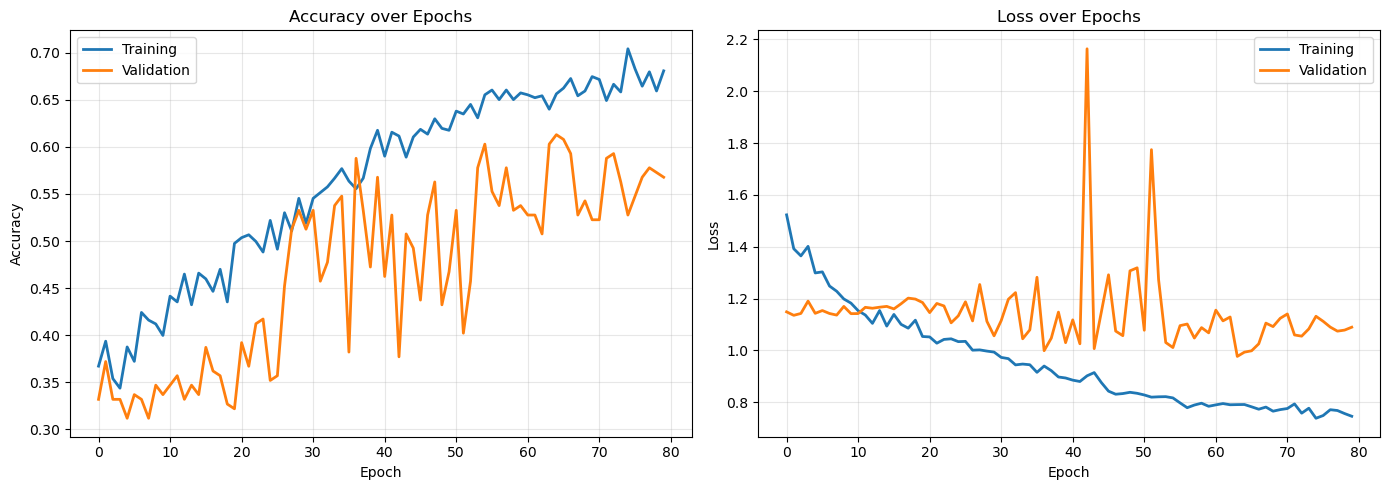

Best epoch:               65
Best validation accuracy: 0.6131
Train acc at best epoch:  0.6565
Train/val gap:            0.0434


In [9]:
h = history.history

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(h['accuracy'], label='Training', linewidth=2)
axes[0].plot(h['val_accuracy'], label='Validation', linewidth=2)
axes[0].set_title('Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(h['loss'], label='Training', linewidth=2)
axes[1].plot(h['val_loss'], label='Validation', linewidth=2)
axes[1].set_title('Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

best_epoch = np.argmax(h['val_accuracy'])
print(f'Best epoch:               {best_epoch + 1}')
print(f'Best validation accuracy: {max(h["val_accuracy"]):.4f}')
print(f'Train acc at best epoch:  {h["accuracy"][best_epoch]:.4f}')
print(f'Train/val gap:            {h["accuracy"][best_epoch] - h["val_accuracy"][best_epoch]:.4f}')

---
## 6.&nbsp; Evaluate on Test Set

In [10]:
test_loss, test_acc = model.evaluate(datasets['test'], verbose=0)
print(f'Test Accuracy:  {test_acc:.4f}')
print(f'Test Loss:      {test_loss:.4f}')
print(f'Parameters:     {model.count_params():,}')
print(f'Training Time:  {train_time/60:.1f} min')

Test Accuracy:  0.6533
Test Loss:      0.9440
Parameters:     250,947
Training Time:  31.9 min


In [11]:
class_names: list[str] = ['A', 'B', 'C']

all_images: list[tf.Tensor] = []
all_labels: list[tf.Tensor] = []
for images, labels in datasets['test']:
    all_images.append(images)
    all_labels.append(labels)

all_images: tf.Tensor = tf.concat(all_images, axis=0)
all_labels: tf.Tensor = tf.concat(all_labels, axis=0)

preds: np.ndarray = model.predict(all_images)
pred_labels: np.ndarray = np.argmax(preds, axis=1)

print(classification_report(all_labels.numpy(), pred_labels, target_names=class_names))

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 167ms/step
              precision    recall  f1-score   support

           A       0.40      0.05      0.08        43
           B       0.56      0.84      0.68        64
           C       0.76      0.80      0.78        92

    accuracy                           0.65       199
   macro avg       0.57      0.56      0.51       199
weighted avg       0.62      0.65      0.60       199



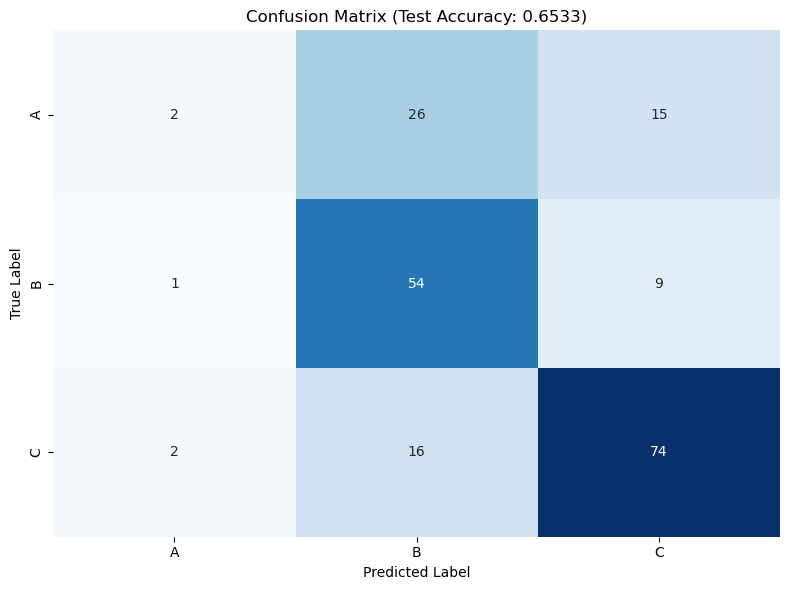

In [12]:
cm: np.ndarray = confusion_matrix(all_labels, pred_labels)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', cbar=False,
    xticklabels=class_names, yticklabels=class_names
)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f'Confusion Matrix (Test Accuracy: {test_acc:.4f})')
plt.tight_layout()
plt.show()

---
## 7.&nbsp; Misclassified Images

Misclassified: 69 out of 199


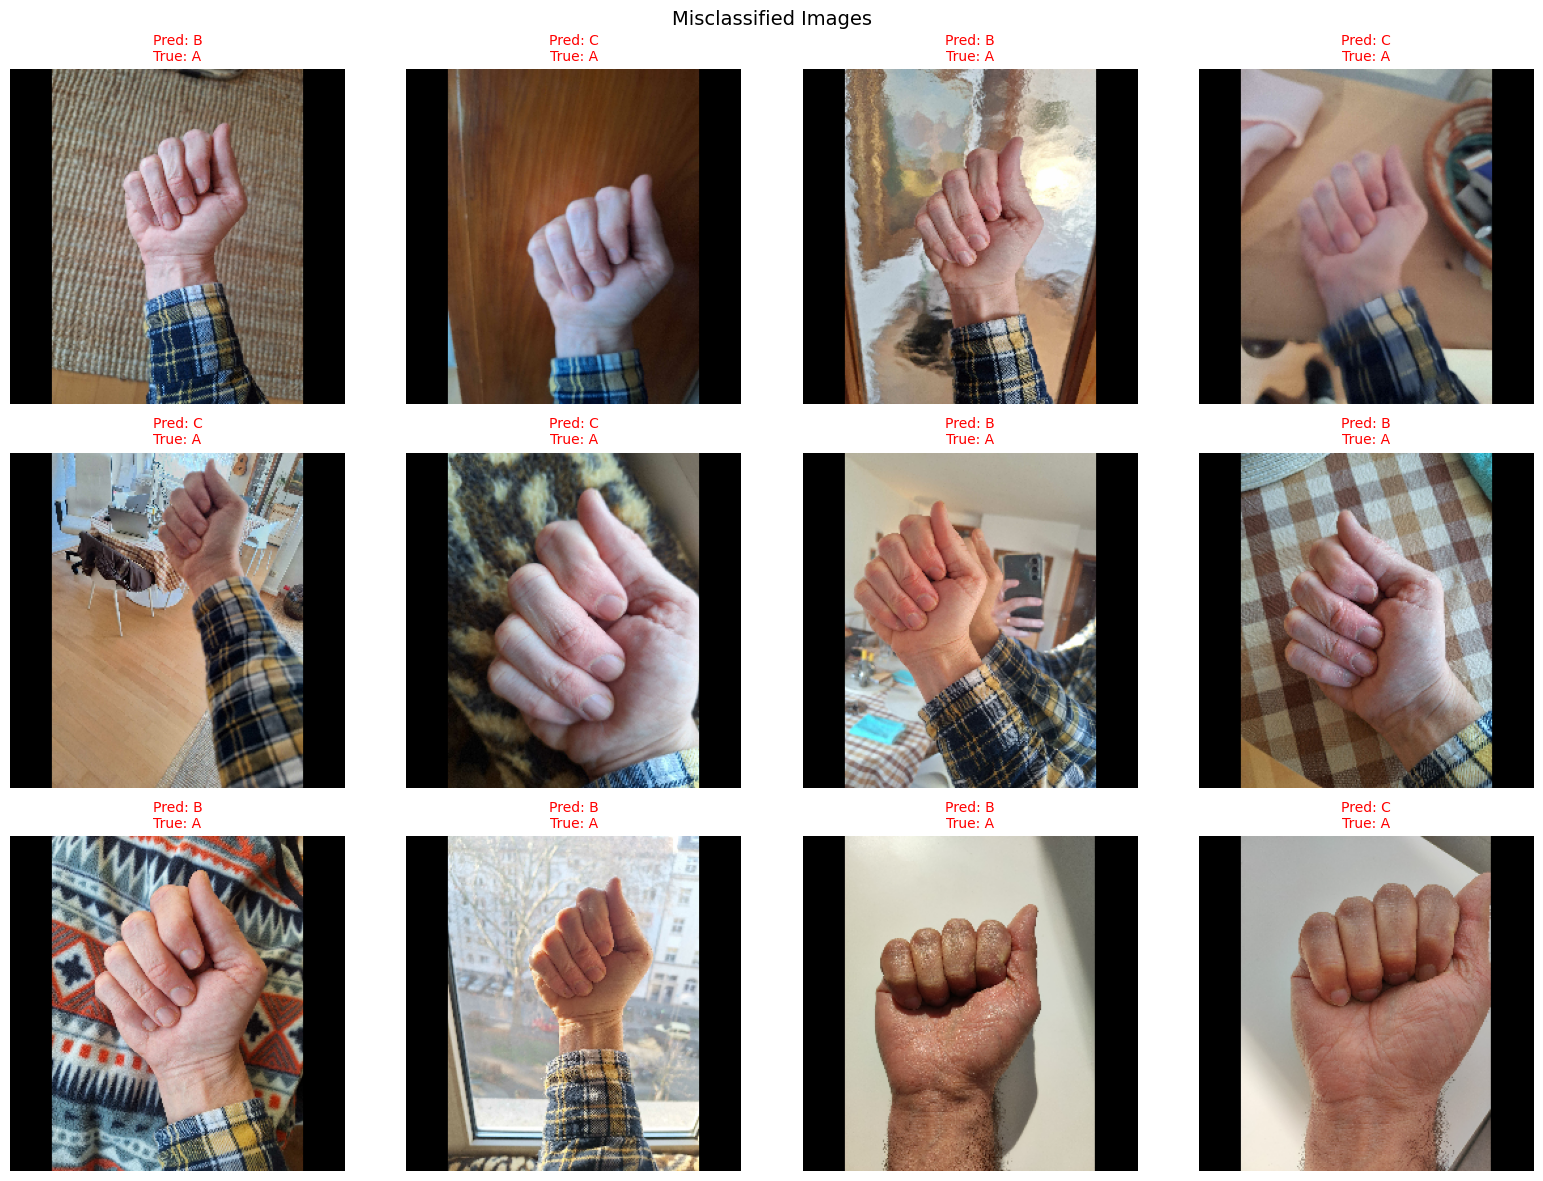

In [13]:
wrong_idx = np.where(pred_labels != all_labels.numpy())[0]
print(f'Misclassified: {len(wrong_idx)} out of {len(all_labels)}')

if len(wrong_idx) > 0:
    n_show = min(12, len(wrong_idx))
    cols = min(4, n_show)
    rows = (n_show + cols - 1) // cols

    plt.figure(figsize=(4 * cols, 4 * rows))
    for i in range(n_show):
        idx = wrong_idx[i]
        plt.subplot(rows, cols, i + 1)
        plt.imshow(all_images[idx].numpy().astype('uint8'))
        plt.title(
            f'Pred: {class_names[pred_labels[idx]]}\nTrue: {class_names[all_labels[idx]]}',
            color='red', fontsize=10
        )
        plt.axis('off')
    plt.suptitle('Misclassified Images', fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print('No misclassifications!')

---
## 8.&nbsp; Save for Competition

The model already accepts raw 256×256 images — no wrapper needed. Just save directly.

In [14]:
# Save without optimizer to reduce file size
model.save('competition_custom_v7.keras', include_optimizer=False)
size_mb = os.path.getsize('competition_custom_v7.keras') / 1e6
print(f'Competition model saved! Size: {size_mb:.1f} MB')

Competition model saved! Size: 3.1 MB


---
## 9.&nbsp; Reflect 📝

1. Did putting preprocessing inside the model improve competition score vs v6?
2. How did the aggressive augmentation (from teaching notebook) affect training?
3. Is the train/val gap reasonable?
4. Compare: from-scratch best vs transfer learning best — what does the gap tell you?

*Write your reflections here:*

- ...
- ...
- ...